### Amanda Cutler Assignment 6

In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [7]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


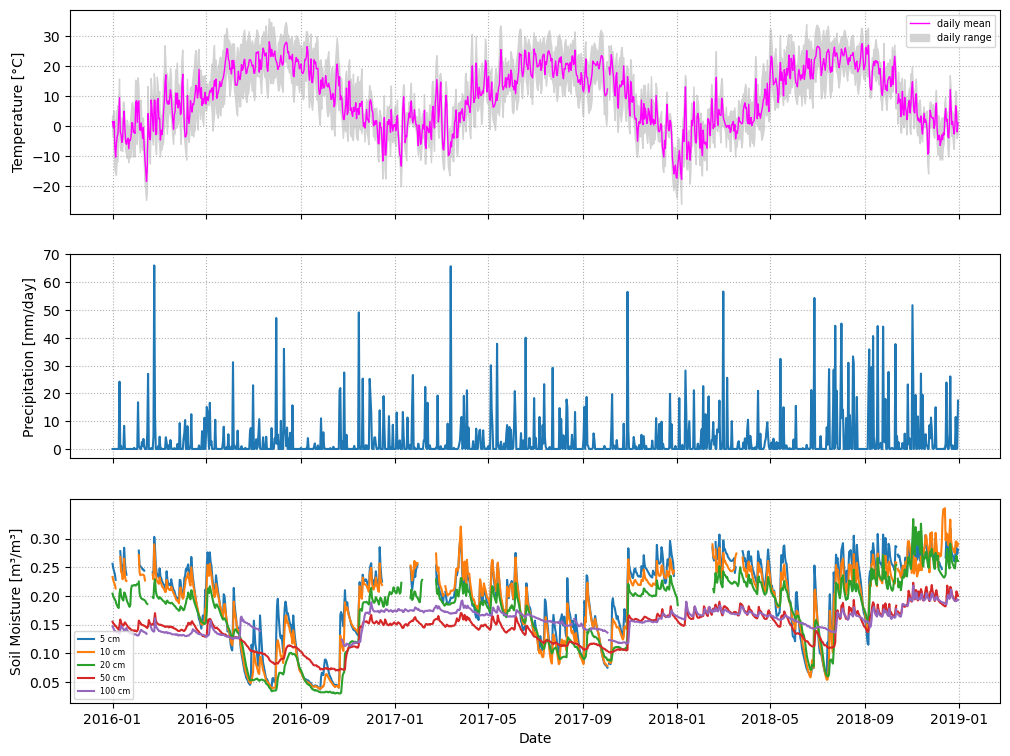

In [11]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 9), sharex=True)
ax[0].plot(date, t_daily_mean, color='magenta', linewidth = 1, label='daily mean')
ax[0].fill_between(date, t_daily_min, t_daily_max, color='lightgray', label='daily range')
ax[0].set_ylabel ('Temperature [°C]')
ax[0].legend(loc='upper right', fontsize='x-small')
ax[0].grid(True)
ax[0].grid(linestyle=':')

ax[1].plot(date, p_daily_calc)
ax[1].set_ylabel ('Precipitation [mm/day]')
ax[1].set_yticks([0,10,20,30,40,50,60,70])
ax[1].grid(True)
ax[1].grid(linestyle=':')

ax[2].plot(date, soil_moisture_5, label='5 cm')
ax[2].plot(date, soil_moisture_10, label='10 cm')
ax[2].plot(date, soil_moisture_20, label='20 cm')
ax[2].plot(date, soil_moisture_50, label='50 cm')
ax[2].plot(date, soil_moisture_100, label='100 cm')
ax[2].set_ylabel ('Soil Moisture [m³/m³]')
ax[2].set_yticks([0.05,0.10,0.15,0.20,0.25,0.30])
ax[2].set_xlabel ('Date')
#ax[2].set_xticks()
ax[2].legend(loc='lower left', fontsize='xx-small')
ax[2].grid(True)
ax[2].grid(linestyle=':')

In [14]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

/home/alc2282/.local/lib/python3.11/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


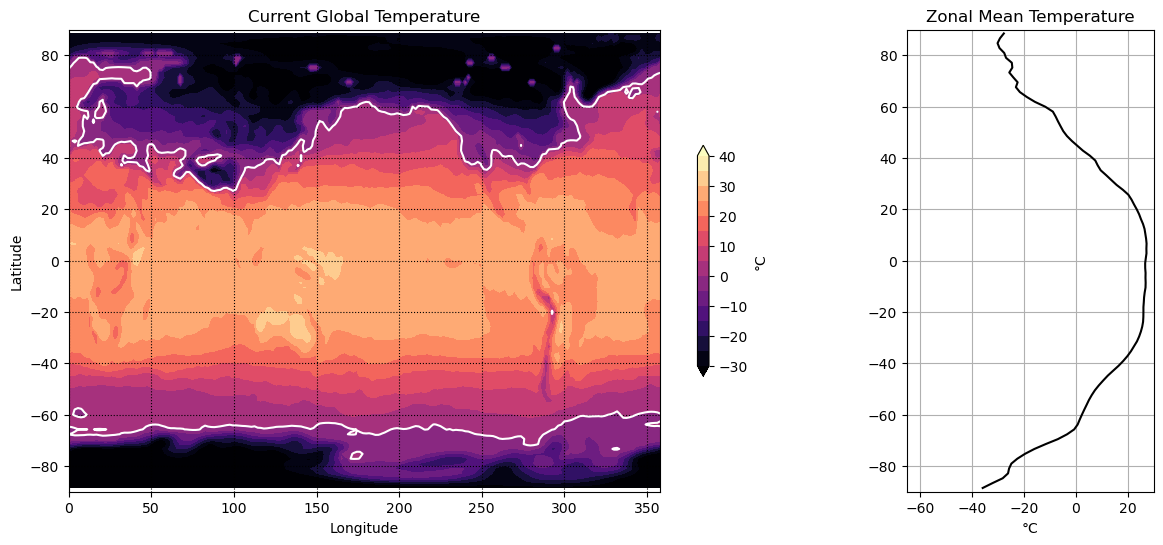

In [74]:
fig, ax = plt.subplots(ncols=2, figsize=(14,6), gridspec_kw={'width_ratios': [3, 1]}, sharey=True)

ax[0].set_title('Current Global Temperature')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')
clevels = np.arange(-30,45,5)
cf0 = ax[0].contourf(lon, lat, temp, levels=clevels, cmap='magma', extend='both')
ax[0].grid(linestyle=':', color='black')
fig.colorbar(cf0, ax=ax[0], label= '°C', shrink=0.5)
ax[0].contour(lon,lat,temp, levels = 0,colors = 'white')

ax[1].set_title('Zonal Mean Temperature')
ax[1].grid()
zonal_mean_temp = np.mean(temp,axis=1)
ax[1].plot(zonal_mean_temp,lat, color='black')
ax[1].set_xlabel('°C')
ax[1].set_xlim(-65,30)
ax[1].set_ylim(-90,90)
ax[1].yaxis.set_tick_params(labelleft=True)

In [15]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/alc2282/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/alc2282/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


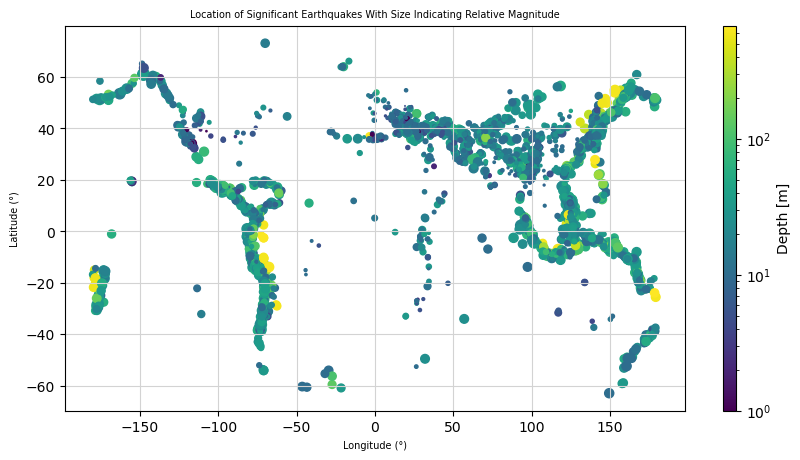

In [104]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(10,5))
splot = ax.scatter(longitude, latitude, c=depth, s=((magnitude**4)/100), norm=LogNorm())
fig.colorbar(splot, label='Depth [m]',aspect=30)
ax.set_xlabel('Longitude (°)',fontsize=7)
ax.set_ylabel('Latitude (°)',fontsize=7)
ax.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude',fontsize=7)
ax.grid(color='lightgray')